#### Import libraries

In [1]:
import sys
import os
import pandas as pd
import numpy as  np
import scanpy as sc
import deconversation
import anndata as ad
deconversation.__file__
from deconversation import embeddings, preprocessing, deconvolution, visualization, evaluation, models

/nfs/home/aoku/.local/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.
geneformer successfully imported.
Cell2Sentence is not installed. Skipping related functions.


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Path to h5ad data
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/tme/10x3v2_lungtumor10_symbol_1000.h5ad"

In [4]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

# Remove unmapped genes
adata.var.index = adata.var["gene_id"]
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer 
adata = preprocessing.load_and_prep_data(adata= adata, cell_type_col= "type", mode="geneformer")

In [5]:
adata.obs["type"].value_counts()

type
B cell                   1000
NK                       1000
TCD4                     1000
TCD8                     1000
epithelial cell          1000
fibroblast               1000
mononuclear phagocyte    1000
malignant cell           1000
endothelial cell          992
mast cell                 571
Name: count, dtype: int64

In [6]:
adata.write_h5ad("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/tme/v800/10x3v2_lungtumor10_id_1000.h5ad")

In [7]:
gf_finetuned_metrics = models.train_geneformer_cell_classifier(adata,
                                                        output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/tme/v800/",
                                                        state_key = "type",
                                                        tokenize = True,
                                                        token_output_prefix = "tokenized", 
                                                        undersample = True,
                                                        n_per_class = 500,
                                                        n_test_per_class = 80,
                                                        eval_fraction = 0.2,
                                                        model_directory = "ctheodoris/Geneformer",
                                                        training_args = {"num_train_epochs": 3},
                                                        output_prefix = "gf_finetune",
                                                        metrics_output_dir = None
                                                       )

2026-09-19 18:01:44,071 [INFO] Training arguments: {'num_train_epochs': 3, 'learning_rate': 5e-05, 'lr_scheduler_type': 'cosine', 'warmup_steps': 190, 'weight_decay': 0.1, 'per_device_train_batch_size': 4, 'gradient_accumulation_steps': 8, 'seed': 42, 'fp16': True}
2026-09-19 18:01:44,072 [INFO] Tokenizing data → /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/tme/v800/tokenized


Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/tme/v800/10x3v2_lungtumor10_id_1000.h5ad


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:06<00:00,  2.82it/s]


/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/tme/v800/10x3v2_lungtumor10_id_1000.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.


2026-09-19 18:03:01,156 [INFO] Tokenization complete: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/tme/v800/tokenized/tokenized.dataset
2026-09-19 18:03:01,162 [INFO] Undersampling: max 500 cells per class
2026-09-19 18:03:01,272 [INFO] Split sizes — train pool: 5000 | test: 791
2026-09-19 18:03:01,291 [INFO] Train: 4000 | Eval: 1000 | Test: 791
2026-09-19 18:03:01,306 [INFO] Preparing data splits…
2026-09-19 18:03:10,108 [INFO] Starting training…


...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.339700,0.164707,0.941000,0.940048
2,0.171700,0.227107,0.930000,0.929672
3,0.125100,0.225229,0.942000,0.942036


  0%|          | 0/100 [00:00<?, ?it/s]

2026-09-19 18:36:26,109 [INFO] Evaluating on test set…


  0%|          | 0/79 [00:00<?, ?it/s]

2026-09-19 18:40:43,178 [INFO] Metrics saved to /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/tme/v800/metrics/gf_finetune_metrics.pkl
2026-09-19 18:40:43,179 [INFO] Done.


In [8]:
conf_matrix = gf_finetuned_metrics["test_metrics"]["conf_matrix"]

In [9]:
# Empty data frame to store fine tuning results 
metrics = pd.DataFrame(index=conf_matrix.index, columns=["Precision", "Recall", "F1", "Accuracy"])

for cls in conf_matrix.columns:
    tp = conf_matrix.loc[cls, cls]  # TP
    fp = conf_matrix[cls].sum() - tp  # FP
    fn = conf_matrix.loc[cls].sum() - tp  # FN
    tn = conf_matrix.values.sum() - (tp + fp + fn)  # TN

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy = (tp + tn) / conf_matrix.values.sum()

    metrics.loc[cls] = [precision, recall, f1, accuracy]

# Convert all to float and round for readability
metrics = metrics.astype(float).round(3)

# Sort by F1 score (descending order)
metrics = metrics.sort_values(by="F1", ascending=False)

print(metrics)

                       Precision  Recall     F1  Accuracy
mononuclear phagocyte      1.000   1.000  1.000     1.000
fibroblast                 1.000   1.000  1.000     1.000
endothelial cell           1.000   1.000  1.000     1.000
mast cell                  0.986   1.000  0.993     0.999
B cell                     0.987   0.975  0.981     0.996
NK                         0.952   0.988  0.969     0.994
TCD4                       0.961   0.912  0.936     0.987
TCD8                       0.902   0.925  0.914     0.982
epithelial cell            0.721   0.938  0.815     0.957
malignant cell             0.945   0.650  0.770     0.961


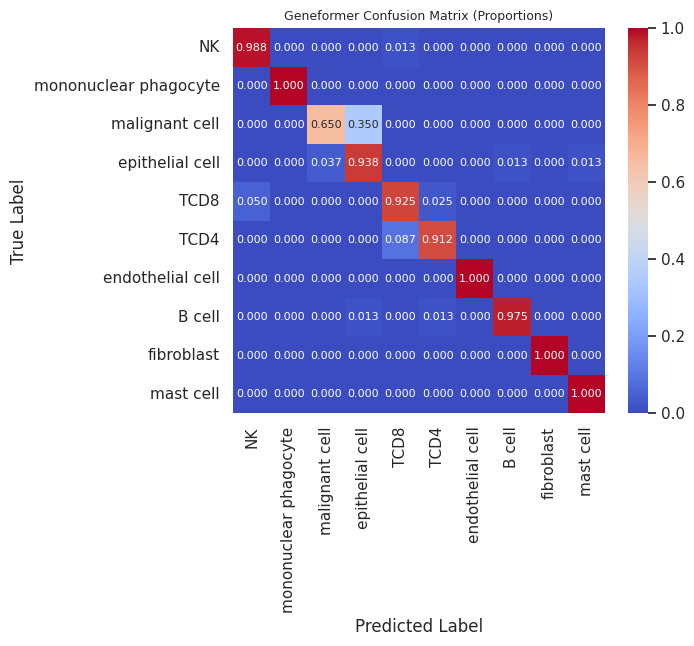

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

conf_matrix = gf_finetuned_metrics["test_metrics"]["conf_matrix"]

# Normalize the confusion matrix to proportions
conf_matrix_row_normalized = conf_matrix.div(conf_matrix.sum(axis=1), axis=0)

# Create the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix_row_normalized, 
    annot=True,                
    fmt=".3f",                 
    cmap="coolwarm",          
    annot_kws={"size": 8}      
)
plt.title("Geneformer Confusion Matrix (Proportions)", fontsize=9)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

In [ ]:
"/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/tme/v800/260919_geneformer_cellClassifier_gf_finetune/ksplit1/"